In [45]:
import torch
import torchvision
from torchvision.transforms import v2

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 10

trainset = torchvision.datasets.CIFAR10(root='./data', train= True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [46]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(3, 6, 5)
    self.pool = nn.MaxPool2d(2,2)
    self.conv2 = nn.Conv2d(6, 16, 5)
    self.fc1 = nn.Linear(16*5*5, 120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84, 10)

  def forward(self, x):
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))
    x = torch.flatten(x, 1)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)

    return x
net = Net()


In [47]:
import torch.optim as optim



criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [58]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.002, momentum=0.9)

In [59]:
for epoch in range(5):
  running_loss = 0.0
  for i, data in enumerate(trainloader, 0):
    inputs, labels = data
    optimizer.zero_grad()
    outputs = net(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
    if i % 2000 == 1999:
      print(f'[{epoch+1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
      running_loss = 0.0
print('Finished Training')
PATH = './cifar_net.pt'
torch.save(net.state_dict(), PATH)



[1,  2000] loss: 1.185
[1,  4000] loss: 1.146
[2,  2000] loss: 1.043
[2,  4000] loss: 1.033
[3,  2000] loss: 0.964
[3,  4000] loss: 0.985
[4,  2000] loss: 0.916
[4,  4000] loss: 0.931
[5,  2000] loss: 0.871
[5,  4000] loss: 0.891
Finished Training


GroundTruth:  cat   ship  ship  plane


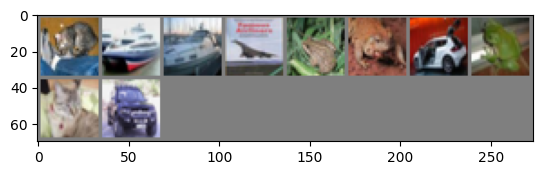

In [55]:
daitaiter = iter(testloader)
images, labels = next(daitaiter)

imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range (4)))

In [56]:
net = Net()
net.load_state_dict(torch.load(PATH, weights_only=True))
outputs = net(images)

_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}' for j in range(4)))


Predicted:  cat   plane ship  ship 


In [60]:
correct = 0
total = 0

with torch.no_grad():
  for data in testloader:
    images, labels = data
    outputs = net(images)
    _, predictions = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (predictions == labels).sum().item()
print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')



Accuracy of the network on the 10000 test images: 60 %


In [42]:
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')


Accuracy for class: plane is 56.5 %
Accuracy for class: car   is 83.5 %
Accuracy for class: bird  is 48.0 %
Accuracy for class: cat   is 40.4 %
Accuracy for class: deer  is 28.3 %
Accuracy for class: dog   is 40.6 %
Accuracy for class: frog  is 53.2 %
Accuracy for class: horse is 49.7 %
Accuracy for class: ship  is 83.7 %
Accuracy for class: truck is 53.9 %
